In [40]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from matplotlib import cycler
from matplotlib.ticker import MultipleLocator

In [41]:
# Data directory (if your data is elsewhere, e.g., /mnt/data/PoseErrors, change here)
ROOT = Path("./PoseErrors")
APE_DIR = ROOT / "APE"
RPE_DIR = ROOT / "RPE"
RPEr_DIR = ROOT / "RPEr"

# Dataset prefixes
DATASETS = ["fr1", "fr2", "fr3"]

# Short tag -> Full name (used for legends)
short_tags  = ["orb", "akz", "kaz", "sft", "bsk", "spp"]
full_names  = ["ORB", "AKAZE", "KAZE", "SIFT", "BRISK", "SuperPoint",]
TAG2NAME: Dict[str, str] = dict(zip(short_tags, full_names))

# Optional: exclude certain features (e.g., if you don’t want to plot BRISK)
EXCLUDE_FEATURES = {"corr"}  # If not needed, set to empty set()

# Unit scaling: 1=meters, 100=centimeters, 1000=millimeters (applies to both APE and RPE)
SCALE = 100.0
Y_UNIT = "cm"

# Which metric to plot: 'mean' (default) or 'rmse' / 'median'
METRIC_KEY = "mean"

# Save figures (optional)
SAVE_FIG = True
FIG_DIR = Path("./ResultFigs"); FIG_DIR.mkdir(parents=True, exist_ok=True)



In [42]:
# === Cell 2: Parsing and collecting series ===
# You can keep only the first few palettes; the more palettes, the more distinct colors available
PALETTES = ("tab20", "tab20b", "tab20c", "Set3", "Set2", "Set1", "Dark2", "Paired", "Accent")

def _many_colors(palettes=PALETTES):
    """Concatenate multiple discrete palettes into one long color list."""
    cols = []
    for name in (palettes if isinstance(palettes, (list, tuple)) else [palettes]):
        cmap = plt.get_cmap(name)
        cols.extend([cmap(i) for i in range(cmap.N)])  # RGBA
    return cols


def parse_20_runs_metrics(txt_path: Path) -> Dict[str, List[float]]:
    """
    Extract per-run sequences for 3 metrics (mean/median/rmse) from a single txt file.
    Return: {"mean":[...], "median":[...], "rmse":[...]} (length = number of runs)
    """
    got = {"mean": [], "median": [], "rmse": []}
    if not txt_path.is_file():
        return got
    key_pat = re.compile(r"^\s*(mean|median|rmse)\s+([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*$", re.I)
    with txt_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = key_pat.match(line)
            if m:
                k = m.group(1).lower()
                v = float(m.group(2))
                got[k].append(v)
    return got

def _stem_to_tags_and_label(stem: str, dataset: str) -> Tuple[List[str], str]:
    """
    Extract tags and a human-readable label from file stem.
    Example: 'fr1_akz_spp' -> (['akz','spp'], 'AKAZE + SuperPoint')
    """
    core = stem
    if core.startswith(dataset + "_"):
        core = core[len(dataset)+1:]
    tags = [t for t in core.split("_") if t]
    if EXCLUDE_FEATURES and set(tags) & EXCLUDE_FEATURES:
        return [], ""
    parts = [(TAG2NAME.get(t, t.upper())) for t in tags]
    label = " + ".join(parts) if parts else core.upper()
    return tags, label

def collect_runs_series(dir_path: Path, dataset: str) -> Dict[str, dict]:
    """
    Collect all per-run sequences for a dataset under dir_path (APE/RPE).
    Return: combo_key -> {
        "label": ...,
        "tags": [...],
        "series": {"mean":[...], "median":[...], "rmse":[...]}
    }
    """
    rows = {}
    prefix = f"{dataset}_"
    for p in sorted(dir_path.glob(f"{prefix}*.txt")):
        stem = p.stem  # e.g., fr1_akz_spp
        tags, label = _stem_to_tags_and_label(stem, dataset)
        if not tags:  # excluded or parsing failed
            continue
        series = parse_20_runs_metrics(p)
        # keep only if any metric has data
        if any(len(v) > 0 for v in series.values()):
            combo_key = stem[len(prefix):]
            rows[combo_key] = {"label": label, "tags": tags, "series": series}
    # Sort: first by number of features, then by label (consistent with pose table)
    rows = dict(sorted(rows.items(), key=lambda kv: (len(kv[1]["tags"]), kv[1]["label"])))
    return rows


In [43]:
def plot_runs_for_dataset(dataset: str, which: str = "APE", metric_key: str = METRIC_KEY):
    """
    which: "APE" or "RPE"
    metric_key: "mean" / "rmse" / "median"
    Overlay all combinations (up to 16) for this dataset in one figure.
    Y-axis is scaled by SCALE and labeled with Y_UNIT.
    """
    assert which in ("APE", "RPE")
    dir_path = APE_DIR if which == "APE" else RPE_DIR

    rows = collect_runs_series(dir_path, dataset)
    if not rows:
        print(f"% No {which} rows for dataset {dataset} in {dir_path}")
        return

    plt.figure(figsize=(12, 6))
    plt.gca().set_prop_cycle(cycler(color=_many_colors()))
    for key, info in rows.items():
        y = info["series"].get(metric_key, [])
        if not y:
            continue
        x = np.arange(1, len(y)+1)
        y_plot = np.asarray(y, float) * SCALE
        # Do not fix color; only set label and light grid
        plt.plot(x, y_plot, label=info["label"])
    plt.xlabel("Run #")
    plt.ylabel(f"{which} ({Y_UNIT})")
    plt.title(f"{dataset.upper()} — {which} per-run ({metric_key})")
    plt.grid(True, alpha=0.3)
    # Legend on the right side to avoid overlap
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.78, 1])

    if SAVE_FIG:
        out = FIG_DIR / f"{dataset}_{which}_{metric_key}_runs.png"
        plt.savefig(out, dpi=200)
        print(f"Saved: {out}")

    plt.show()


def plot_runs_both_for_dataset(dataset: str, metric_key: str = METRIC_KEY):
    """For the same dataset, plot two figures: APE and RPE."""
    plot_runs_for_dataset(dataset, "APE", metric_key)
    plot_runs_for_dataset(dataset, "RPE", metric_key)


# === New: Map transparency by mean value + APE/RPE in one figure + right-side legend panel ===

def _alpha_map_from_means(series_map: dict, a_lo=0.25, a_hi=1.0):
    """
    Input: {key: {"y": np.array, ...}}
    Output: {key: alpha} — smaller mean → closer to a_hi (more opaque).
    """
    if not series_map:
        return {}
    means = [float(np.mean(v["y"])) for v in series_map.values()]
    mn, mx = min(means), max(means)
    amap = {}
    for k, v in series_map.items():
        m = float(np.mean(v["y"]))
        if mx - mn > 1e-12:
            # Linear mapping (small → large): smaller mean -> higher alpha
            a = a_hi - (m - mn) / (mx - mn) * (a_hi - a_lo)
        else:
            a = a_hi
        amap[k] = float(a)
    return amap


def plot_runs_pair_with_ref(
    dataset: str,
    metric_key: str = "mean",
    # Explicit y-axis ranges (e.g., 0~0.2). If None, adapt to data
    ymin_ape: float = None, ymax_ape: float = None,
    ymin_rpe: float = None, ymax_rpe: float = None,
    # Transparency range (smaller mean → higher alpha)
    alpha_min: float = 0.25, alpha_max: float = 1.0,
    # Line width
    linewidth: float = 1.6,
):
    import numpy as np
    import matplotlib.pyplot as plt

    # Use your existing collect_runs_series to gather and scale data
    def _collect(dir_path, dataset):
        rows = collect_runs_series(dir_path, dataset)
        out = {}
        for key, info in rows.items():
            y = info["series"].get(metric_key, [])
            if not y:
                continue
            y = np.asarray(y, float) * SCALE
            out[key] = {"label": info["label"], "y": y}
        return out

    ape = _collect(APE_DIR, dataset)
    rpe = _collect(RPE_DIR, dataset)
    if not ape and not rpe:
        print(f"% No APE/RPE series for {dataset}")
        return

    # Transparency mapping (computed separately for APE and RPE)
    alpha_ape = _alpha_map_from_means(ape, alpha_min, alpha_max)
    alpha_rpe = _alpha_map_from_means(rpe, alpha_min, alpha_max)

    # One figure: left column = 2 subplots (APE top, RPE bottom), right column = legend panel
    fig = plt.figure(figsize=(12, 5), constrained_layout=True)
    gs  = fig.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 1], wspace=0.025, hspace=0.0)
    axA = fig.add_subplot(gs[0, 0])   # APE (top)
    axR = fig.add_subplot(gs[1, 0])   # RPE (bottom)
    axT = fig.add_subplot(gs[:, 1])   # right-side panel
    cols = _many_colors()
    axA.set_prop_cycle(cycler(color=cols))
    axR.set_prop_cycle(cycler(color=cols))
    axA.xaxis.set_major_locator(MultipleLocator(1))
    axR.xaxis.set_major_locator(MultipleLocator(1))

    # ---- APE
    handles_A, labels_A = [], []
    if ape:
        for key, item in ape.items():
            y = item["y"]; x = np.arange(1, len(y)+1)
            h, = axA.plot(x, y, alpha=alpha_ape.get(key, 1.0), linewidth=linewidth, label=item["label"])
            handles_A.append(h); labels_A.append(item["label"])
        if (ymin_ape is not None) or (ymax_ape is not None):
            axA.set_ylim(ymin_ape, ymax_ape)
        axA.set_ylabel(f"APE ({Y_UNIT})")
        axA.grid(True, alpha=0.3)

    # ---- RPE
    handles_R, labels_R = [], []
    if rpe:
        for key, item in rpe.items():
            y = item["y"]; x = np.arange(1, len(y)+1)
            h, = axR.plot(x, y, alpha=alpha_rpe.get(key, 1.0), linewidth=linewidth, label=item["label"])
            handles_R.append(h); labels_R.append(item["label"])
        if (ymin_rpe is not None) or (ymax_rpe is not None):
            axR.set_ylim(ymin_rpe, ymax_rpe)
        axR.set_xlabel("Run Number")
        axR.set_ylabel(f"RPE ({Y_UNIT})")
        axR.grid(True, alpha=0.3)

    # ---- Right-side: combined legend (using handles/labels above)
    axT.axis("off")
    # Merge APE + RPE legends (avoid duplicates)
    lab2handle = {}
    for h, lb in list(zip(handles_A, labels_A)) + list(zip(handles_R, labels_R)):
        lab2handle[lb] = h
    # Place legend in the right panel
    axT.legend(list(lab2handle.values()), list(lab2handle.keys()),
               loc="upper left", fontsize=9, frameon=True)

    if SAVE_FIG:
        out = FIG_DIR / f"{dataset}_pose_error.png"
        plt.savefig(out, dpi=200)
        print(f"Saved: {out}")

    plt.show()

    plt.show()


Saved: ResultFigs/fr1_pose_error.png


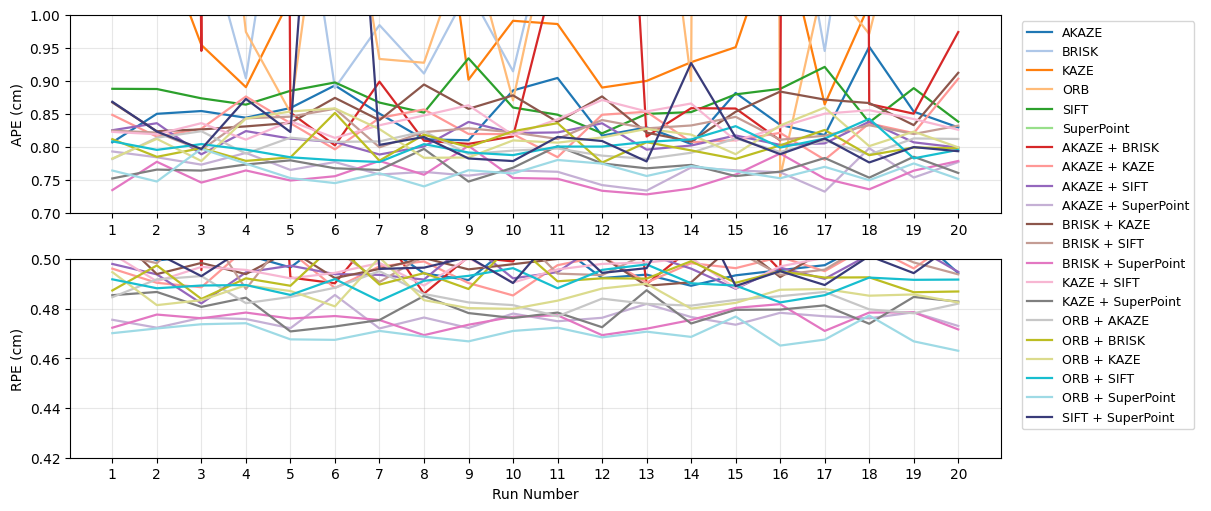

In [44]:

# One-click generation of APE/RPE line plots for fr1 / fr2 / fr3 (call as needed)
# for ds in DATASETS:
#     plot_runs_both_for_dataset(ds, METRIC_KEY)

plot_runs_pair_with_ref(
    "fr1",
    metric_key="mean",
    ymin_ape=0.7, ymax_ape=1,
    ymin_rpe=0.42, ymax_rpe=0.5,
    alpha_min=1.0, alpha_max=1.0
)


Saved: ResultFigs/fr2_pose_error.png


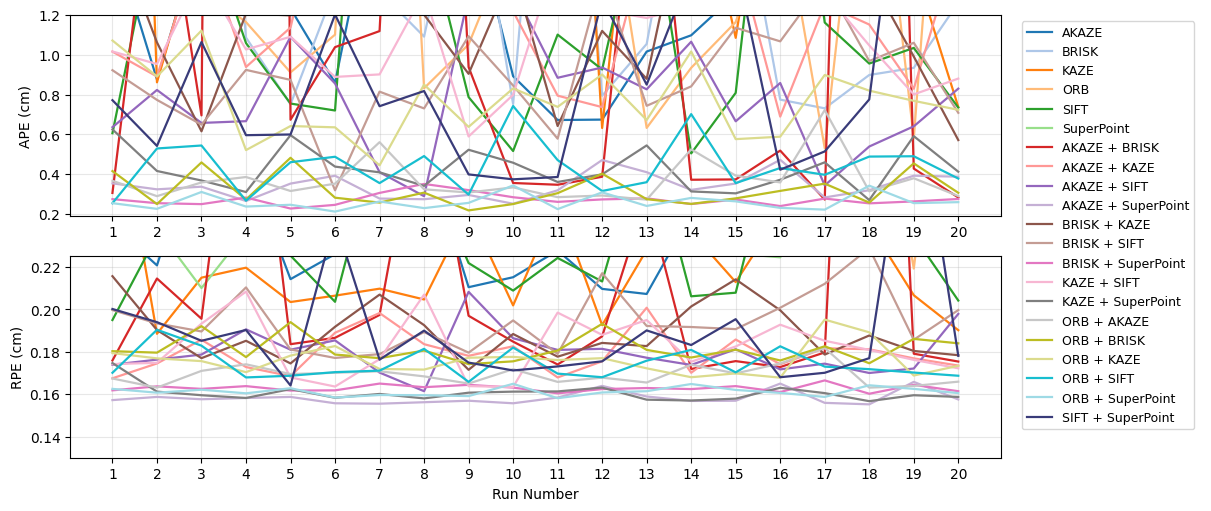

In [45]:
plot_runs_pair_with_ref(
    "fr2",
    metric_key="mean",
    ymin_ape=0.19, ymax_ape=1.2,
    ymin_rpe=0.13, ymax_rpe=0.225,
    alpha_min=1.0, alpha_max=1.0
)


Saved: ResultFigs/fr3_pose_error.png


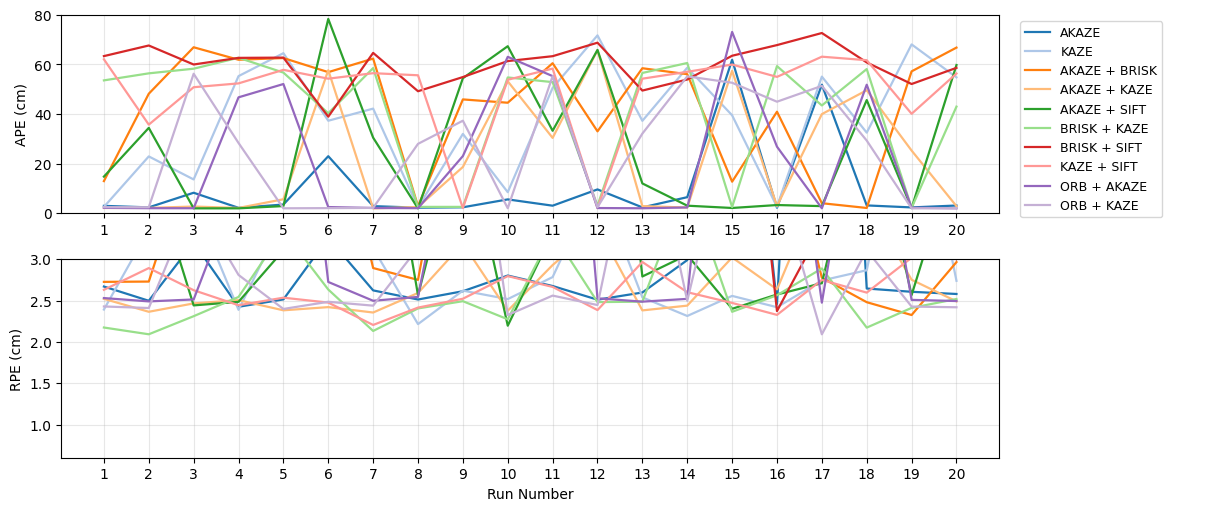

In [46]:
EXCLUDE_FEATURES = {"corr", "spp"}

plot_runs_pair_with_ref(
    "fr3",
    metric_key="mean",
    ymin_ape=0, ymax_ape=80,
    ymin_rpe=0.6, ymax_rpe=3,
    alpha_min=1.0, alpha_max=1.0
)


### Boxplot helpers have been appended below.

In [47]:

# === Boxplot Utilities (Matplotlib only; one chart per plot; no explicit colors) ===
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import re

def _infer_label_from_filename(dataset: str, path: Path) -> str:
    """Infer a readable feature-combination label from a filename like:
    fr1_xyz_ORB_0001.txt  -> ORB
    fr1_xyz_ORB+SIFT_run12.txt -> ORB+SIFT
    Fallback: use the stem after the dataset prefix.
    """
    name = path.stem
    prefix = f"{dataset}_"
    core = name[len(prefix):] if name.startswith(prefix) else name
    tokens = core.split("_")
    keep = []
    for t in tokens:
        # Stop when token looks like a run index or a common suffix
        if t.isdigit() or t.lower().startswith("run") or t.lower().startswith("result"):
            break
        keep.append(t)
    label = "_".join(keep) if keep else core
    return label

def collect_runs_series_simple(dir_path: Path, dataset: str, metric_key: str = "rmse"):
    """Lightweight fallback collector if your original `collect_runs_series` isn't present.
    It scans `dir_path` for `<dataset>_*.txt` and regex-parses `rmse`/`mean`/`median` values.
    Returns a dict: {label -> [values across runs]}.
    """
    data = defaultdict(list)
    if not Path(dir_path).exists():
        return {}
    pattern = f"{dataset}_*.txt"
    for p in sorted(Path(dir_path).glob(pattern)):
        try:
            text = p.read_text(encoding="utf-8", errors="ignore")
        except Exception:
            continue
        m = None
        key = metric_key.lower()
        num = r"([\-+]?\d+(?:\.\d+)?(?:[eE][\-+]?\d+)?)"
        if key == "rmse":
            m = re.search(rf"(?i)\brmse\b[^0-9\-+e.]*{num}", text)
        elif key == "mean":
            m = re.search(rf"(?i)\bmean\b[^0-9\-+e.]*{num}", text)
        elif key == "median":
            m = re.search(rf"(?i)\bmedian\b[^0-9\-+e.]*{num}", text)
        if not m:
            continue
        val = float(m.group(1))
        label = _infer_label_from_filename(dataset, p)
        data[label].append(val)
    return dict(data)

def plot_boxplot_from_dict(series_dict: dict, *,
                           title: str = None,
                           y_label: str = None):
    """Directly draw a boxplot from {label: [values]} dict.

    Returns (fig, ax)."""
    if not series_dict:
        print("% Empty series_dict")
        return None
    labels = sorted(series_dict.keys())
    data = [np.asarray(series_dict[l], float) for l in labels]

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    ax.boxplot(data, patch_artist=False, showmeans=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(integer=False))
    if y_label:
        ax.set_ylabel(y_label)
    if title:
        ax.set_title(title)
    ax.grid(True, which='both', axis='y', alpha=0.3)
    fig.tight_layout()
    return fig, ax

def plot_boxplot_for_dataset(dataset: str,
                             which: str = "APE",
                             metric_key: str = "rmse",
                             scale: float = 1.0,
                             y_unit: str = "",
                             exclude: set = None):
    """Draw a per-combination boxplot for a dataset using your existing directory layout.
    - which: "APE" or "RPE"
    - metric_key: "rmse" | "mean" | "median"
    - scale: multiply all values (e.g., 100 for m->cm)
    - y_unit: label suffix, e.g., "cm"
    - exclude: case-insensitive substrings to filter labels (e.g., {"corr", "spp"})
    Returns (fig, ax, meta) or None if no data.
    """
    which_u = which.upper()
    dir_path = APE_DIR if which_u == "APE" else RPE_DIR if which_u == "RPE" else RPEr_DIR
    # Try the user's original collector first if available
    series_dict = {}
    if 'collect_runs_series' in globals():
        rows = collect_runs_series(dir_path, dataset)  # expected: {label: {"series": {metric_key: [...]}}}
        for key, info in rows.items():
            vals = info.get('series', {}).get(metric_key, [])
            if vals:
                series_dict[key] = [float(v) for v in vals]
    else:
        series_dict = collect_runs_series_simple(dir_path, dataset, metric_key)

    # Exclude certain labels if requested
    if exclude:
        series_dict = {k: v for k, v in series_dict.items()
                       if not any(sub in k.lower() for sub in (s.lower() for s in exclude))}

    if not series_dict:
        print(f"% No data found for dataset={dataset}, which={which}, metric={metric_key} in {dir_path}")
        return None

    # Apply scaling and plot
    labels = sorted(series_dict.keys())
    data = [np.asarray(series_dict[l], float) * float(scale) for l in labels]

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    ax.boxplot(data, patch_artist=False, showmeans=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(integer=False))
    ax.set_xlabel("Feature combination")
    ylab = metric_key.upper()
    if y_unit:
        ylab = f"{ylab} [{y_unit}]"
    ax.set_ylabel(ylab)
    ax.set_title(f"{dataset} — {which_u} {metric_key.upper()} Boxplot (per run)")
    ax.grid(True, which='both', axis='y', alpha=0.3)
    fig.tight_layout()

    meta = {"labels": labels, "data": data, "dir_path": str(dir_path)}
    return fig, ax, meta

def save_boxplot(fig, dataset: str, which: str, metric_key: str, outdir: str = "figs"):
    outdir_p = Path(outdir)
    outdir_p.mkdir(parents=True, exist_ok=True)
    path = outdir_p / f"boxplot_{dataset}_{which}_{metric_key}.png"
    fig.savefig(str(path), dpi=200, bbox_inches='tight')
    print(f"Saved to: {path}")
    return str(path)

# --- Example (commented): ---
# EXCLUDE_FEATURES = {"corr", "spp"}
# ret = plot_boxplot_for_dataset("fr1_xyz", which="APE", metric_key="rmse", scale=100, y_unit="cm", exclude=EXCLUDE_FEATURES)
# if ret is not None:
#     fig, ax, meta = ret
#     save_boxplot(fig, "fr1_xyz", "APE", "rmse")


### Boxplot v2 (with more controls)

In [48]:

# === Boxplot v2: with ylim/log/whis/showfliers/sort/jitter knobs ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_boxplot_for_dataset_v2(dataset: str,
                                which: str = "APE",
                                metric_key: str = "rmse",
                                scale: float = 100,
                                y_unit: str = "cm",
                                y_spec: str = "",
                                exclude: set = None,
                                ylim: tuple | None = None,
                                log_y: bool = True,
                                whis = (0, 100),
                                showfliers: bool = True,
                                sort_by: str | None = "mean",  # "median" | "mean" | None
                                jitter: bool = True,
                                ax = None):
    """Enhanced boxplot with common knobs.
    - whis: whisker extent; e.g., (5,95) shows 5–95 percentile as whiskers.
    - showfliers: whether to draw points beyond whiskers.
    - sort_by: reorder groups by 'median' or 'mean' to improve readability.
    - jitter: overlay raw points with light jitter to show density.
    """
    which_u = which.upper()
    dir_path = APE_DIR if which_u == "APE" else RPE_DIR if which_u == "RPET" else RPEr_DIR

    # Get series_dict using the best available collector
    series_dict = {}
    if 'collect_runs_series' in globals():
        rows = collect_runs_series(dir_path, dataset)
        for key, info in rows.items():
            vals = info.get('series', {}).get(metric_key, [])
            if vals:
                series_dict[key] = [float(v) for v in vals]
    else:
        series_dict = collect_runs_series_simple(dir_path, dataset, metric_key)

    # Exclude labels
    if exclude:
        series_dict = {k: v for k, v in series_dict.items()
                       if not any(sub in k.lower() for sub in (s.lower() for s in exclude))}
    if not series_dict:
        print(f"% No data found for dataset={dataset}, which={which}, metric={metric_key} in {dir_path}")
        return None

    labels = sorted(series_dict.keys())
    data = [np.asarray(series_dict[l], float) * float(scale) for l in labels]

    # Reorder by statistic if requested
    if sort_by in ("median", "mean"):
        stats = [np.median(d) if sort_by == "median" else np.mean(d) for d in data]
        order = np.argsort(stats)
        labels = [labels[i].upper() for i in order]
        data = [data[i] for i in order]

    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 3))
    else:
        fig = ax.figure
    ax.boxplot(data, patch_artist=False, showmeans=True, whis=whis, showfliers=showfliers)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(integer=False))
    #ax.set_xlabel("Feature combination")
    ylab = metric_key.upper()
    if y_unit:
        ylab = f"{y_spec}{ylab} [{y_unit}]"
    ax.set_ylabel(ylab)
    #ax.set_title(f"{dataset} — {which_u} {metric_key.upper()} Boxplot (Sorted by {sort_by.upper()})")
    #ax.grid(True, which='both', axis='y', alpha=0.3)

    if log_y:
        ax.set_yscale("log")

    if ylim is not None:
        ax.set_ylim(*ylim)

    # Optional: overlay raw points with jitter
    if jitter:
        for i, d in enumerate(data, start=1):
            x = np.random.normal(loc=i, scale=0.1, size=len(d))
            ax.plot(x, d, '.', alpha=0.35, markersize=3)

    fig.tight_layout()
    meta = {"labels": labels, "data": data, "dir_path": str(dir_path)}
    return fig, ax, meta

# Example (commented):
# ret = plot_boxplot_for_dataset_v2("fr1", which="APE", metric_key="rmse", scale=100, y_unit="cm",
#                                   exclude={"corr", "spp"}, ylim=(0.8, 1.6),
#                                   whis=(5,95), showfliers=False, sort_by="median", jitter=True)


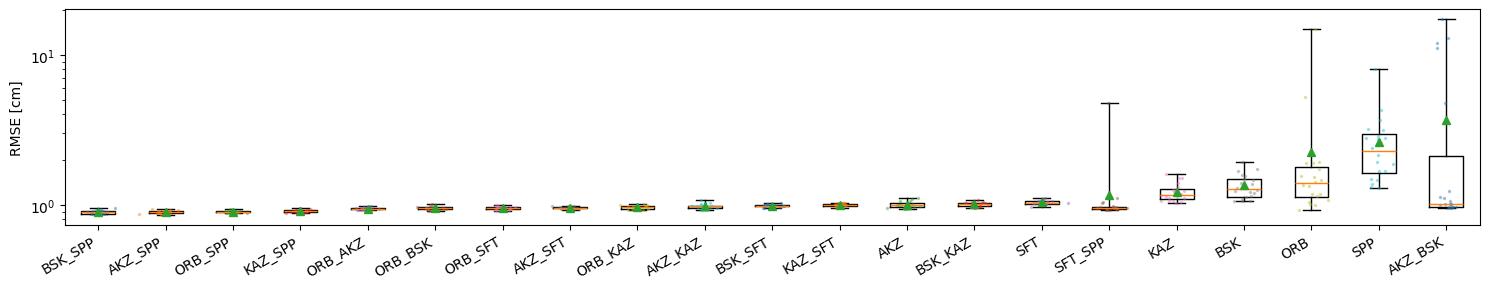

In [49]:
EXCLUDE_FEATURES = {"corr"}  # 可选

ret = plot_boxplot_for_dataset_v2(
    "fr1",
    which="APE",
    metric_key="rmse",
    scale=100,
    y_unit="cm",
    exclude=EXCLUDE_FEATURES,
    #ylim=(0.0, 10),
    #whis=1.5,
    log_y=True,
    showfliers=False,
    sort_by="mean",
    jitter=True
)

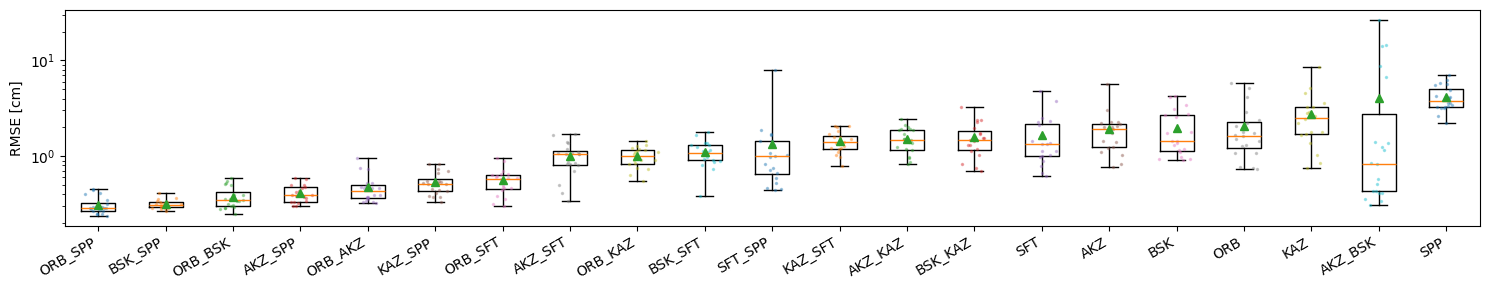

In [50]:
EXCLUDE_FEATURES = {"corr"}  # 可选

ret = plot_boxplot_for_dataset_v2(
    "fr2",
    which="APE",
    metric_key="rmse",
    scale=100,
    y_unit="cm",
    exclude=EXCLUDE_FEATURES,
    log_y=True,
    #ylim=(0.0, 10),
    #whis=1.5,
    showfliers=False,
    sort_by="mean",
    jitter=True
)

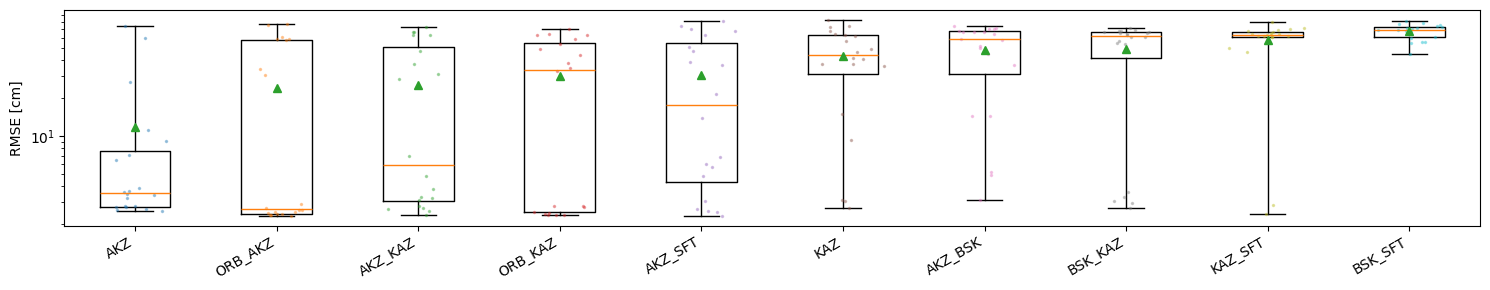

In [51]:
EXCLUDE_FEATURES = {"corr", "spp"}

ret = plot_boxplot_for_dataset_v2(
    "fr3",
    which="APE",
    metric_key="rmse",
    scale=100,
    y_unit="cm",
    exclude=EXCLUDE_FEATURES,
    log_y=True,
    #ylim=(0.0, 10),
    #whis=1.5,
    showfliers=False,
    sort_by="mean",
    jitter=True
)

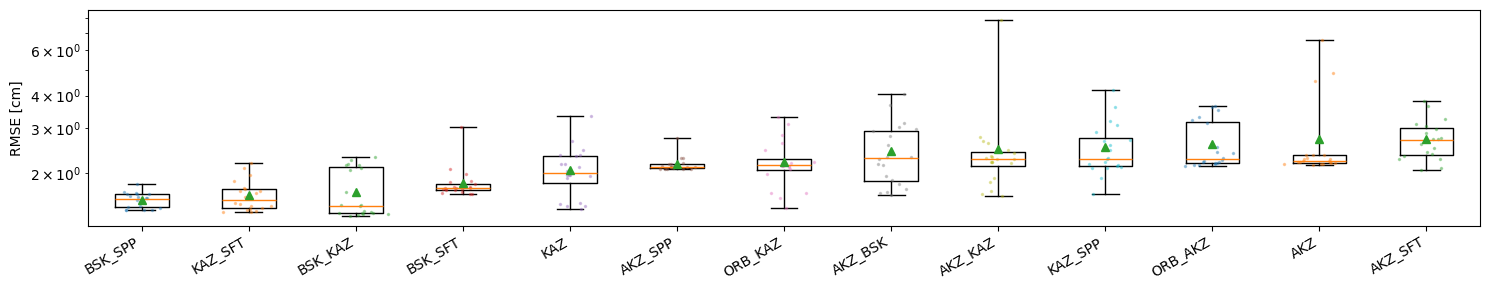

In [52]:
EXCLUDE_FEATURES = {"corr"}  # 可选

ret = plot_boxplot_for_dataset_v2(
    "fr3",
    which="RPEr",
    metric_key="rmse",
    scale=100,
    y_unit="cm",
    exclude=EXCLUDE_FEATURES,
    #ylim=(0.5, 1),
    #whis=1.5,
    log_y=True,
    showfliers=False,
    sort_by="mean",
    jitter=True
)

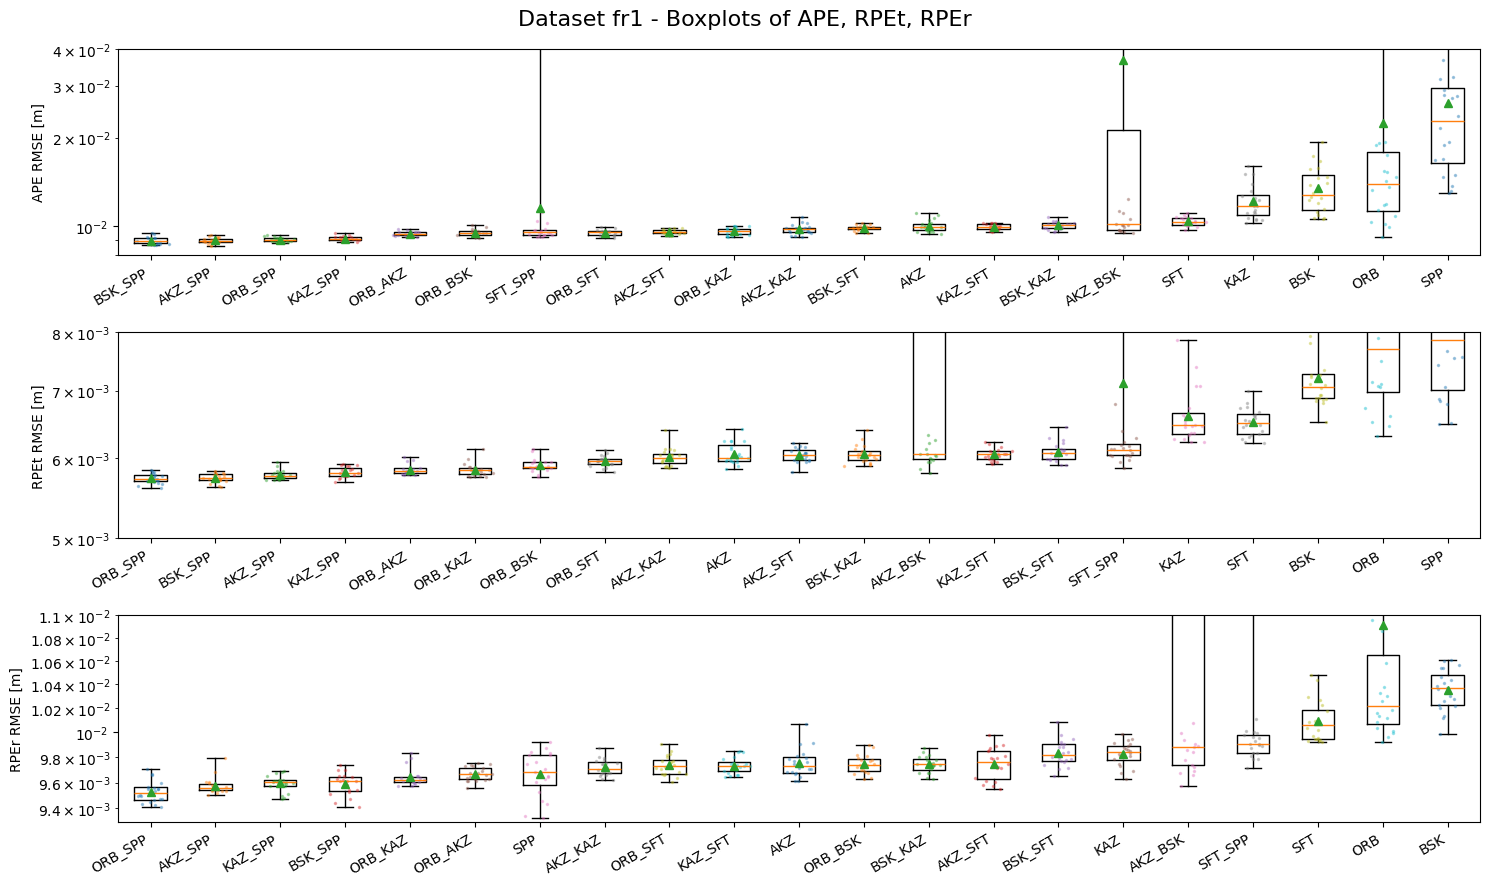

In [53]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "fr1"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr", fontsize=16)
ylims = [(0.008, 0.04), (0.005, 0.008), (0.0093, 0.011)]
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1,
        ylim=ylims[i],
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=True,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

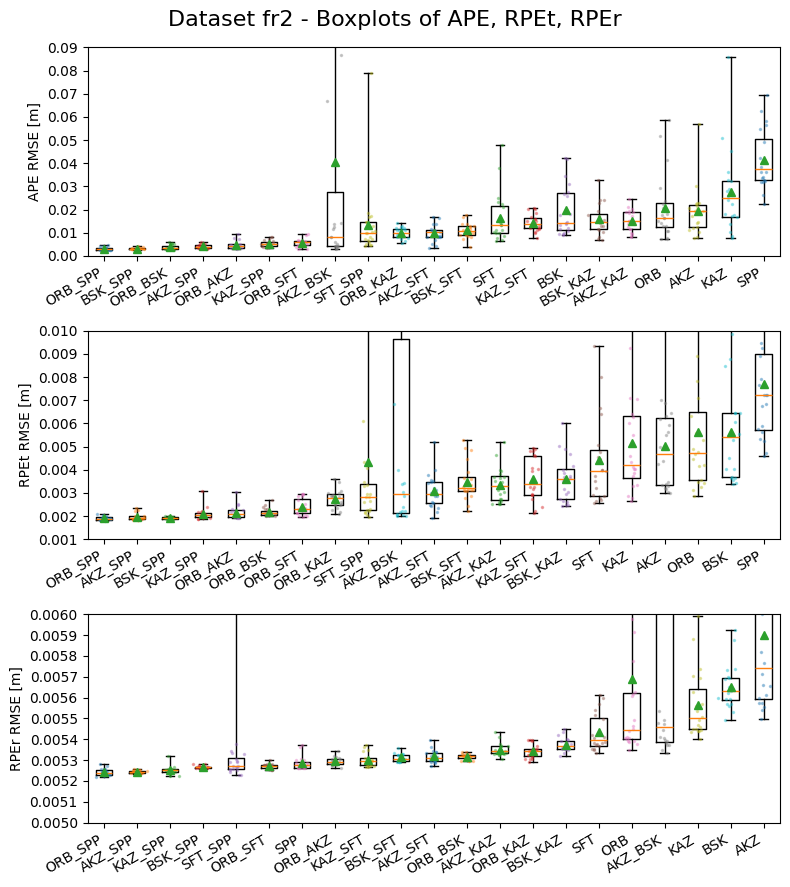

In [54]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(8, 9))
dataset = "fr2"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr", fontsize=16)
ylims = [(0.000, 0.09), (0.001, 0.01), (0.005, 0.006)]
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1,
        ylim=ylims[i],
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )
fig.savefig(f"./ResultFigs/{dataset}_boxplots.pdf", bbox_inches="tight")

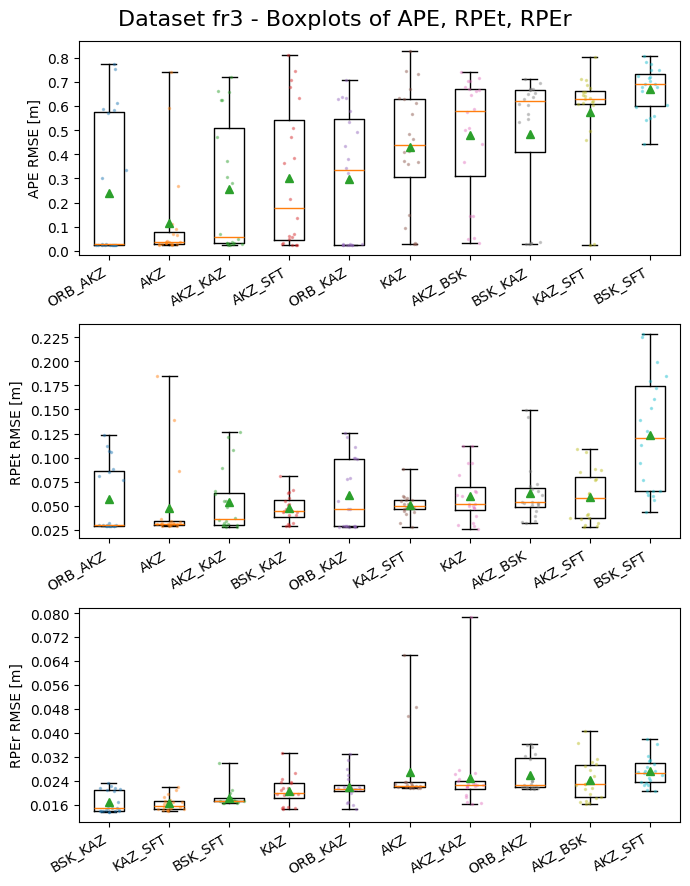

In [55]:
EXCLUDE_FEATURES = {"corr", "spp"}
fig, axes = plt.subplots(3, 1, figsize=(7, 9))
dataset = "fr3"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

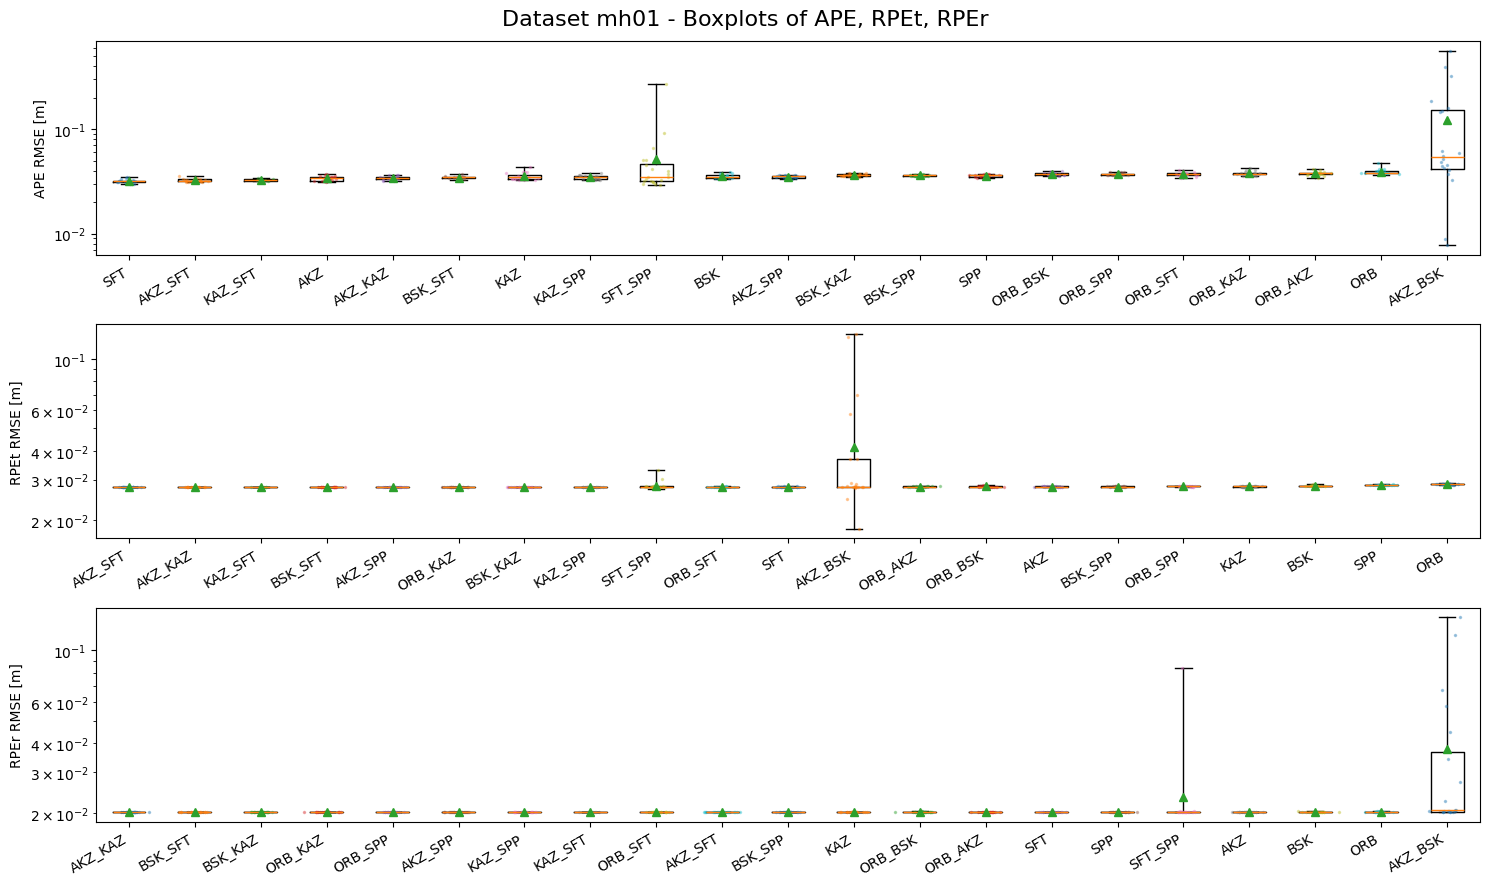

In [56]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "mh01"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=True,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

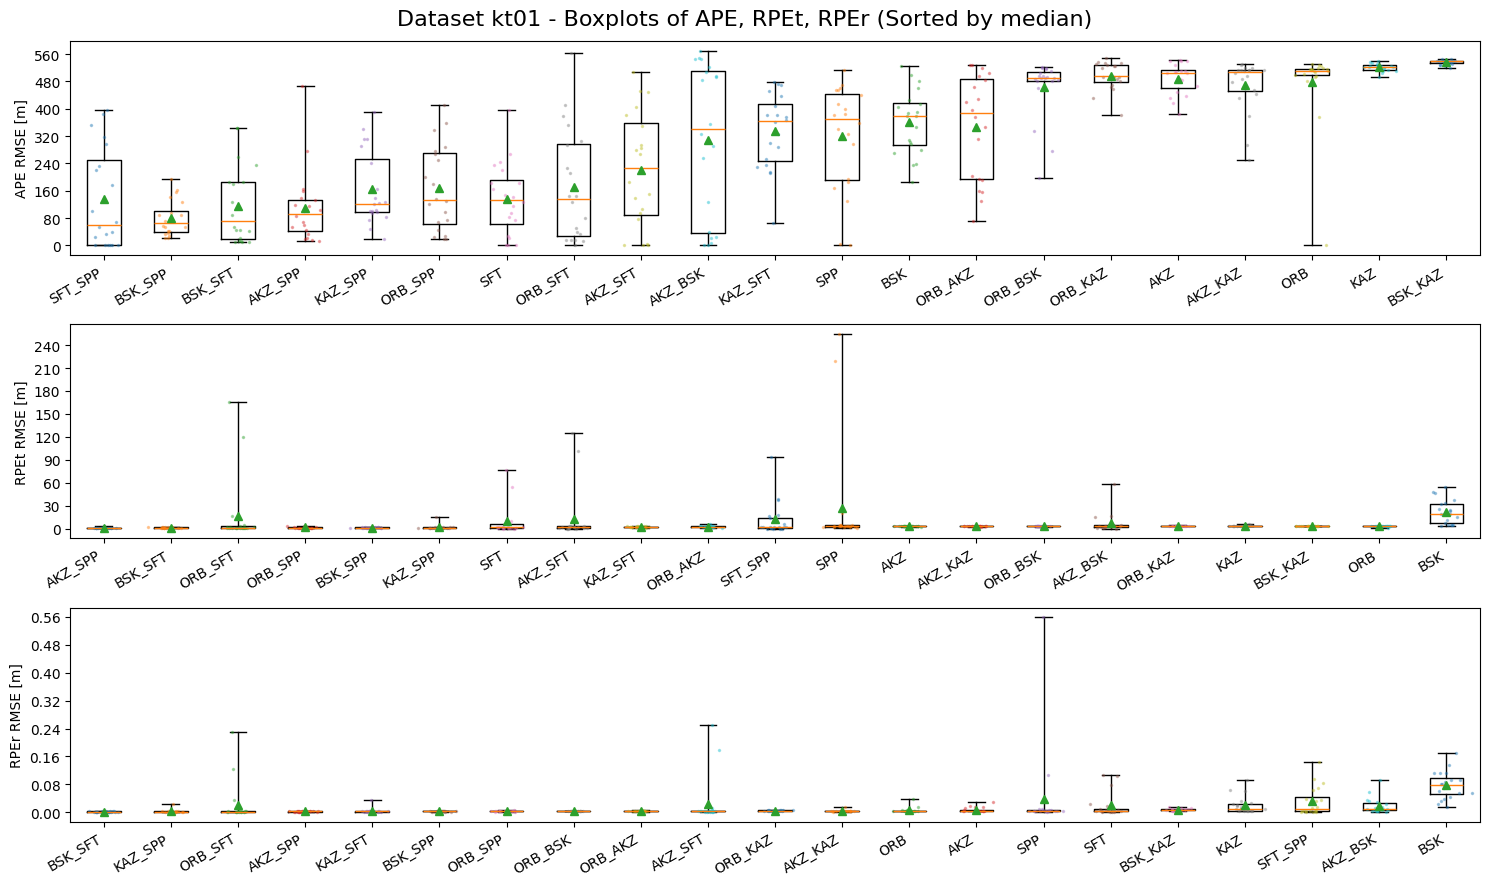

In [70]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "kt01"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr (Sorted by median)", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

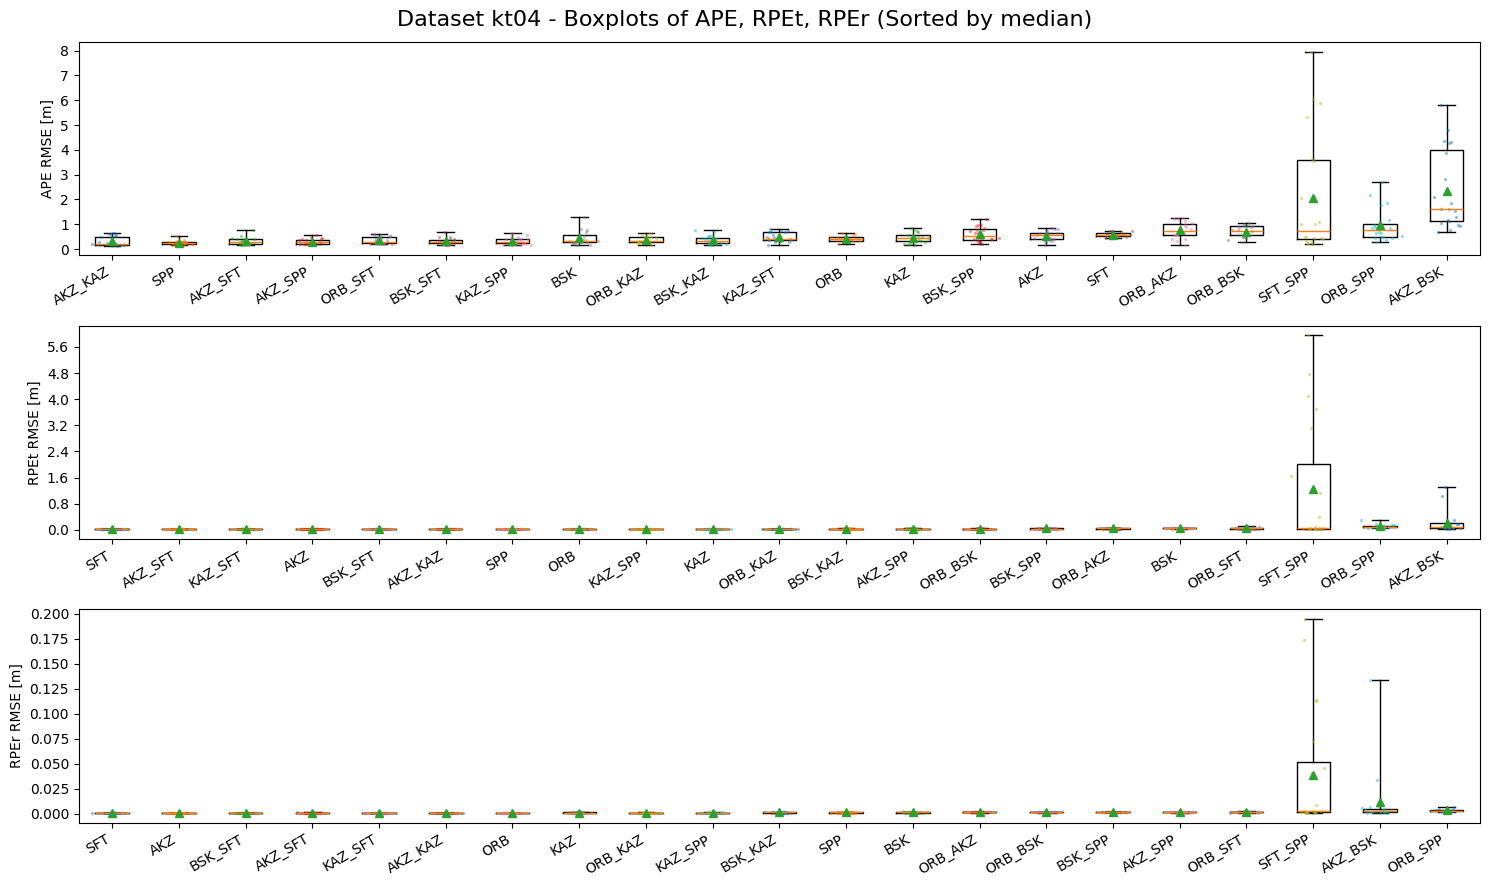

In [58]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "kt04"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr (Sorted by median)", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

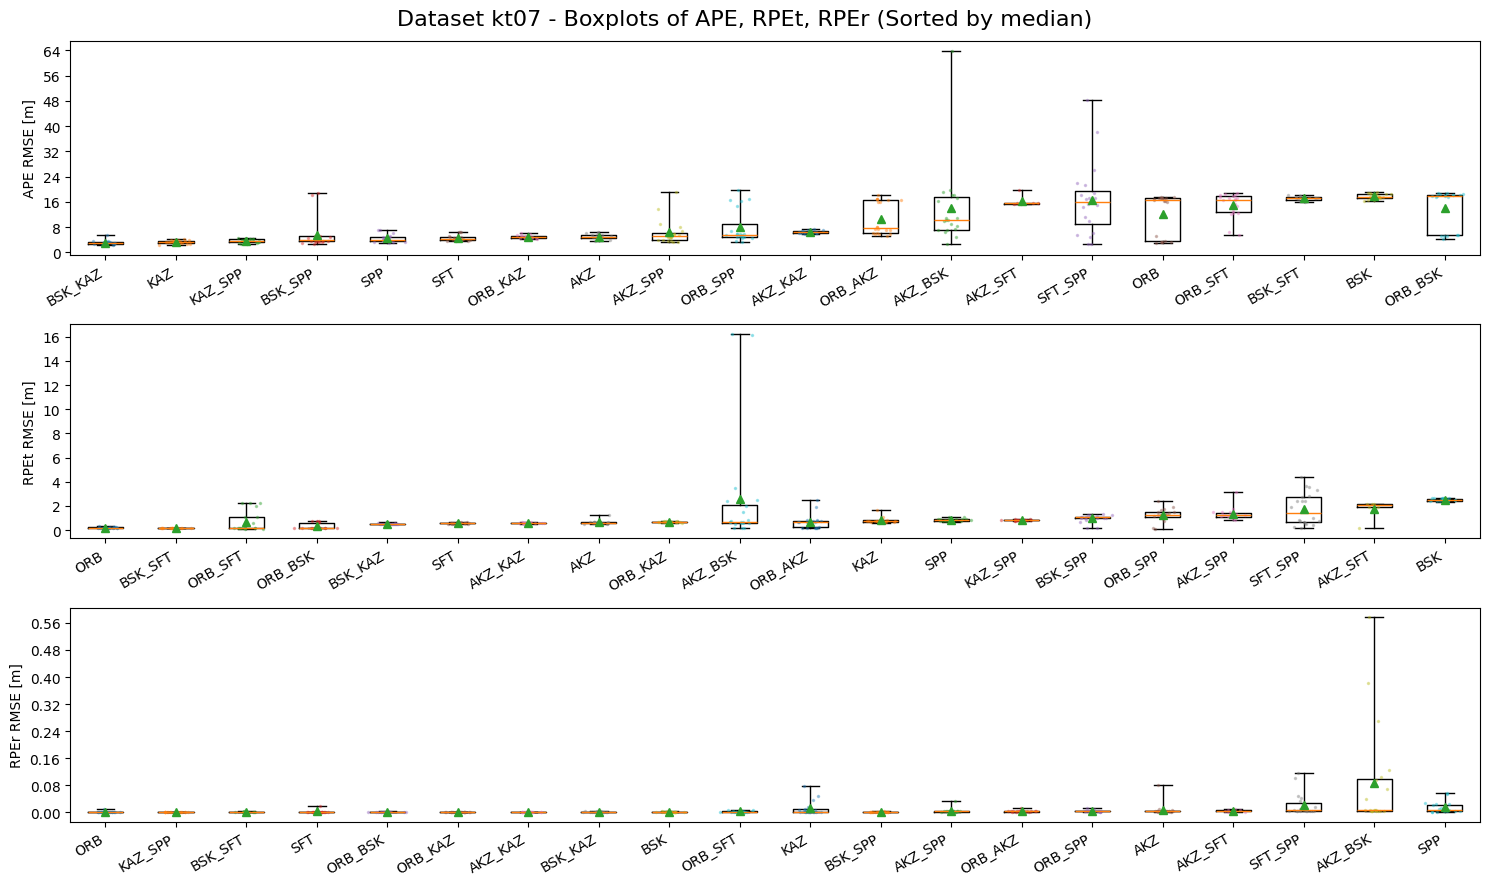

In [59]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "kt07"
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr (Sorted by median)", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

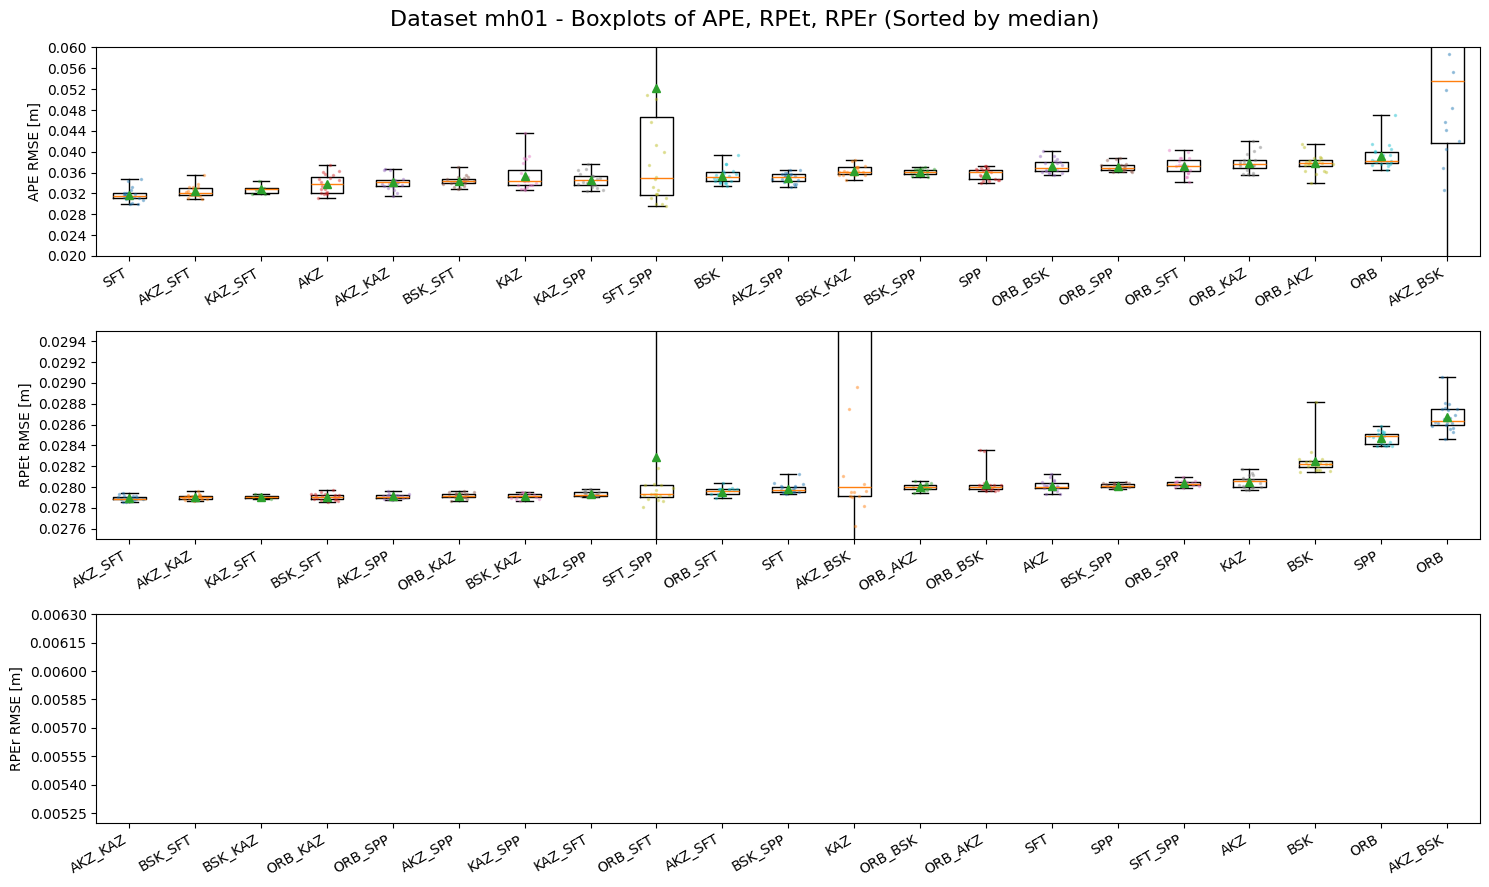

In [60]:
EXCLUDE_FEATURES = {"corr"}
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
dataset = "mh01"
ylims = [(0.02, 0.06), (0.0275, 0.0295), (0.0052, 0.0063)]
fig.suptitle(f"Dataset {dataset} - Boxplots of APE, RPEt, RPEr (Sorted by median)", fontsize=16)
for i, metric in enumerate(["APE", "RPEt", "RPEr"]):
    plot_boxplot_for_dataset_v2(
        dataset,
        which=metric,
        metric_key="rmse",
        scale=1,
        y_unit="m",
        ylim=ylims[i],
        #whis=1.5,
        y_spec=f"{metric} ",
        exclude=EXCLUDE_FEATURES,
        log_y=False,
        showfliers=False,
        sort_by="median",
        jitter=True,
        ax=axes[i]
    )

In [61]:
# This cell adds a small utility to your notebook to generate **minimal PGFPlots (TikZ) boxplots**
# ...
from typing import Dict, List, Tuple, Optional
import numpy as np
import os
from datetime import datetime

def _have_symbol(name: str) -> bool:
    return name in globals()

def _maybe_dir(which: str) -> Optional[str]:
    candidates = []
    if which == "APE":
        candidates = ["APE_DIR"]
    elif which in ("RPEt", "RPE"):
        candidates = ["RPEt_DIR", "RPE_DIR"]
    elif which == "RPEr":
        candidates = ["RPEr_DIR", "RPER_DIR", "RPErot_DIR"]
    for c in candidates:
        if c in globals():
            return globals()[c]
    return None

def _get_groups_for(dataset: str, which: str, metric_key: str, exclude: set) -> Dict[str, List[float]]:
    if "collect_runs_series" in globals():
        dir_path = _maybe_dir(which)
        if dir_path is None:
            raise RuntimeError(f"Directory for {which} not found. Please set e.g. APE_DIR / RPEt_DIR / RPEr_DIR.")
        rows = globals()["collect_runs_series"](dir_path, dataset)
        groups = {}
        for key, info in rows.items():
            if any(x in key for x in exclude):
                continue
            series = info.get("series", {})
            vals = series.get(metric_key, [])
            vals = [float(v) for v in vals if v is not None]
            if len(vals) > 0:
                groups[key] = vals
        return groups

    # Fallback synthetic
    rng = np.random.default_rng(42 if dataset == "fr2" else 0)
    synth = {
        "ORB":  (rng.normal(0.02, 0.002, 20), rng.normal(0.004, 0.0004, 20), rng.normal(0.0057, 0.0001, 20)),
        "AKAZE":(rng.normal(0.03, 0.003, 20), rng.normal(0.006, 0.0006, 20), rng.normal(0.0058, 0.0001, 20)),
        "BRISK":(rng.normal(0.05, 0.004, 20), rng.normal(0.008, 0.0006, 20), rng.normal(0.0059, 0.0001, 20)),
    }
    idx = {"APE":0, "RPEt":1, "RPE":1, "RPEr":2}[which]
    out = {k:list(map(float, v[idx])) for k,v in synth.items() if not any(x in k for x in exclude)}
    return out

def _sorting_order(groups: Dict[str, List[float]], sort_by_median: bool) -> List[str]:
    if not sort_by_median:
        return list(groups.keys())
    meds = [(k, float(np.median(v))) for k, v in groups.items()]
    meds.sort(key=lambda kv: kv[1])
    return [k for k,_ in meds]

def _values_to_pgf_table_block(values, precision: int=6) -> str:
    lines = ["data"]
    lines += [f"{v:.{precision}f}" for v in values]
    inner = "\n".join(lines)
    return (
        "\\addplot [boxplot]\n"
        "table[row sep=newline, y index=0]{\n"
        f"{inner}\n"
        "};"
    )

def _metric_ylabel(which: str) -> str:
    if which == "APE":
        return "APE RMSE (m)"
    if which in ("RPEt", "RPE"):
        return "RPE$_t$ RMSE (m)"
    if which == "RPEr":
        return "RPE$_r$ (rad)"
    return which

def _auto_ylim(groups: Dict[str, List[float]],
               pad: float = 0.06,
               q: Tuple[float, float] = (0.1, 0.9)) -> Tuple[float, float]:
    """
    Robust auto y-limits using percentiles (q) and padding (pad).
    q=(0.01, 0.99) means use 1%~99% percentile to ignore extreme outliers.
    """
    vals = np.array([x for vs in groups.values() for x in vs], dtype=float)
    if vals.size == 0:
        return (0.0, 1.0)
    lo = float(np.quantile(vals, q[0]))
    hi = float(np.quantile(vals, q[1]))
    # 防止 lo==hi
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.min(vals))
        hi = float(np.max(vals))
        if hi <= lo:
            hi = lo + 1e-9
    span = hi - lo
    lo2 = lo - pad * span
    hi2 = hi + pad * span
    lo2 = max(0.0, lo2)
    return (lo2, hi2)


def generate_tikz_boxplots(dataset: str,
                           metrics=("APE","RPEt","RPEr"),
                           metric_key="rmse",
                           exclude={"corr"},
                           sort_by_median=True,
                           show_xtick_labels=False,
                           ylims: Optional[Dict[str, Tuple[float,float]]] = None,
                           precision:int=6,
                           width_frac:float=0.9,
                           height_cm:float=2.5,
                           auto_ylim_percentile: Tuple[float,float]=(0.00,0.95),
                           auto_ylim_pad: float=0.01) -> str:

    """
    Returns a complete LaTeX figure environment (TikZ+PGFPlots) string.
    Also writes it to /mnt/data/boxplot_{dataset}.tex
    """
    metric_groups = {}
    metric_orderings = {}
    for which in metrics:
        groups = _get_groups_for(dataset, which, metric_key, exclude or set())
        if not groups:
            raise RuntimeError(f"No data for dataset={dataset}, which={which}.")
        order = _sorting_order(groups, sort_by_median)
        metric_groups[which] = {k: groups[k] for k in order}
        metric_orderings[which] = order

    lines = []
    lines.append("\\begin{figure}[t]")
    lines.append("\\centering")
    lines.append("\\begin{tikzpicture}")
    lines.append("\\scriptsize")
    lines.append("\\begin{groupplot}[")
    lines.append(f"  group style={{group size=1 by {len(metrics)}, vertical sep=24pt}},")
    lines.append("  boxplot/draw direction=y,")
    lines.append("  scale only axis,")
    lines.append(f"  width="+("{:.2f}".format(width_frac))+"\\linewidth, height="+("{:.1f}".format(height_cm))+"cm,")
    lines.append("  ymajorgrids,")
    lines.append("  scaled y ticks=false,")
    lines.append("  ymode=linear,")
    lines.append("  enlarge x limits=0.05,")
    lines.append("  boxplot/draw outliers=false,")
    lines.append("  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},")
    lines.append("  y tick scale label code/.code={},")
    # ================================================
    if not show_xtick_labels:
        lines.append("  xtick=\\empty,")
    lines.append("  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},")
    lines.append("  boxplot/draw outliers=false,")
    lines.append("  boxplot/every outlier/.style={draw=none,mark=none},")
    lines.append("  boxplot/box extend=0.8,")
    lines.append("  boxplot/every median/.style={red}")
    lines.append("]")

    for which in metrics:
        # y 轴范围
        if ylims and which in ylims:
           ymin, ymax = ylims[which]
        else:
            ymin, ymax = _auto_ylim(metric_groups[which],
                        pad=auto_ylim_pad,
                        q=auto_ylim_percentile)

        # 需要 x 轴标签时
        tick_opts = ""
        if show_xtick_labels:
            keys   = list(metric_groups[which].keys())
            ticks  = ",".join(str(i+1) for i in range(len(keys)))
            labels = ",".join(k.replace("_","\\_") for k in keys)
            tick_opts = (
                f", xtick={{ {ticks} }}, xticklabels={{ {labels.upper()} }}, "
                f"xticklabel style={{rotate=45, anchor=east, font=\\tiny}}"
            )

        # 先 nextgroupplot
        lines.append(
            f"\\nextgroupplot[style={{font=\\tiny}}, ylabel={{{_metric_ylabel(which)}}}, "
            f"ymin={ymin:.{precision}f}, ymax={ymax:.{precision}f}, ymode=linear{tick_opts}]"
        )

        # 再 addplot
        for gname, values in metric_groups[which].items():
            lines.append(_values_to_pgf_table_block(values, precision=precision))

    lines.append("\\end{groupplot}")
    lines.append("\\end{tikzpicture}")
    lines.append(f"\\caption{{TUM \\texttt{{{dataset}}}: APE / RPE$_t$ / RPE$_r$ Boxplot{'Sorted by Median' if sort_by_median else ''}.}}")
    lines.append("\\end{figure}")

    latex = "\n".join(lines)

    out_path = f"./ResultFigs/boxplot_{dataset}.tex"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write("% Auto-generated on " + datetime.now().isoformat() + "\n")
        # 需要这两个库
        f.write("% Requires: \\usepackage{tikz}, \\usepackage{pgfplots}, \\pgfplotsset{compat=1.18}, \\usepgfplotslibrary{groupplots,statistics}\\\n")
        f.write(latex)
    print(f"Saved LaTeX snippet to: {out_path}")
    return latex

# # --- Demo run here (uses synthetic data in this environment) ---
# demo = generate_tikz_boxplots(dataset="fr2",
#                               exclude={"corr"},
#                               sort_by_median=True,
#                               show_xtick_labels=False,
#                               ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)})
# print(demo)


In [62]:
latex = generate_tikz_boxplots(
    dataset="fr1",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)


Saved LaTeX snippet to: ./ResultFigs/boxplot_fr1.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=0.008480, ymax=0.019359, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21 }, xticklabels={ BSK\_SPP,AKZ\_SPP,ORB\_SPP,KAZ\_SPP,ORB\_AKZ,ORB\_BSK,SFT\_SPP,ORB\_SFT,AKZ\_SFT,ORB\_KAZ,AKZ\_KAZ,BSK\_

In [63]:
latex = generate_tikz_boxplots(
    dataset="fr2",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)

Saved LaTeX snippet to: ./ResultFigs/boxplot_fr2.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=0.001987, ymax=0.042250, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21 }, xticklabels={ ORB\_SPP,BSK\_SPP,ORB\_BSK,AKZ\_SPP,ORB\_AKZ,KAZ\_SPP,ORB\_SFT,AKZ\_BSK,SFT\_SPP,ORB\_KAZ,AKZ\_SFT,BSK\_

In [64]:
latex = generate_tikz_boxplots(
    dataset="fr3",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)

Saved LaTeX snippet to: ./ResultFigs/boxplot_fr3.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=0.011638, ymax=0.754408, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13 }, xticklabels={ BSK\_SPP,AKZ\_SPP,ORB\_AKZ,AKZ,AKZ\_KAZ,AKZ\_SFT,ORB\_KAZ,KAZ,KAZ\_SPP,AKZ\_BSK,BSK\_KAZ,KAZ\_SFT,BSK\_SFT }, xticklabel style={

In [65]:
latex = generate_tikz_boxplots(
    dataset="kt01",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)

Saved LaTeX snippet to: ./ResultFigs/boxplot_kt01.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=0.000000, ymax=543.737367, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21 }, xticklabels={ SFT\_SPP,BSK\_SPP,BSK\_SFT,AKZ\_SPP,KAZ\_SPP,ORB\_SPP,SFT,ORB\_SFT,AKZ\_SFT,AKZ\_BSK,KAZ\_SFT,SPP,BSK

In [66]:
latex = generate_tikz_boxplots(
    dataset="kt04",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)

Saved LaTeX snippet to: ./ResultFigs/boxplot_kt04.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=0.129875, ymax=1.633388, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21 }, xticklabels={ AKZ\_KAZ,SPP,AKZ\_SFT,AKZ\_SPP,ORB\_SFT,BSK\_SFT,KAZ\_SPP,BSK,ORB\_KAZ,BSK\_KAZ,KAZ\_SFT,ORB,KAZ,BSK\_S

In [67]:
latex = generate_tikz_boxplots(
    dataset="kt07",
    exclude={"corr"},
    sort_by_median=True,
    show_xtick_labels=True,   # ← 打开
    #ylims={"APE":(0.002,0.09), "RPEt":(0.0014,0.010), "RPEr":(0.0052,0.0063)},
)
print(latex)

Saved LaTeX snippet to: ./ResultFigs/boxplot_kt07.tex
\begin{figure}[t]
\centering
\begin{tikzpicture}
\scriptsize
\begin{groupplot}[
  group style={group size=1 by 3, vertical sep=24pt},
  boxplot/draw direction=y,
  scale only axis,
  width=0.90\linewidth, height=2.5cm,
  ymajorgrids,
  scaled y ticks=false,
  ymode=linear,
  enlarge x limits=0.05,
  boxplot/draw outliers=false,
  yticklabel style={/pgf/number format/fixed,/pgf/number format/precision=4},
  y tick scale label code/.code={},
  every boxplot/.style={fill=gray!20, draw=black, thick, mark=none},
  boxplot/draw outliers=false,
  boxplot/every outlier/.style={draw=none,mark=none},
  boxplot/box extend=0.8,
  boxplot/every median/.style={red}
]
\nextgroupplot[style={font=\tiny}, ylabel={APE RMSE (m)}, ymin=2.118163, ymax=18.815932, ymode=linear, xtick={ 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20 }, xticklabels={ BSK\_KAZ,KAZ,KAZ\_SPP,BSK\_SPP,SPP,SFT,ORB\_KAZ,AKZ,AKZ\_SPP,ORB\_SPP,AKZ\_KAZ,ORB\_AKZ,AKZ\_BSK,AKZ\_SFT